# 2-1

### 2-1-2


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

# Compute mean and std before normalization
train_means_before = X_train.mean(axis=0)
train_stds_before = X_train.std(axis=0)

# Normalize using Min-Max
scaler = MinMaxScaler().fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

# Compute mean and std after normalization
train_means_after = X_train_norm.mean(axis=0)
train_stds_after = X_train_norm.std(axis=0)

# Adaline labels (-1, +1)
y_train_ada = np.where(y_train == 0, -1, 1)
y_test_ada = np.where(y_test == 0, -1, 1)

# Class balance
unique, counts = np.unique(y_train, return_counts=True)
class_balance_df = pd.DataFrame({
    "Class": [data.target_names[i] for i in unique],
    "Count": counts,
    "Percentage": np.round(100 * counts / len(y_train), 2)
})

print("=== Class Balance (Training Set) ===")
print(class_balance_df.to_string(index=False))

# Compare mean & std before and after normalization
stats_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean (Before)": np.round(train_means_before, 4),
    "Std (Before)": np.round(train_stds_before, 4),
    "Mean (After MinMax)": np.round(train_means_after, 4),
    "Std (After MinMax)": np.round(train_stds_after, 4)
})

pd.set_option("display.max_rows", None)
print("\n=== Feature Statistics Before and After Min-Max Normalization ===")
print(stats_df)


=== Class Balance (Training Set) ===
    Class  Count  Percentage
malignant    148       37.19
   benign    250       62.81

=== Feature Statistics Before and After Min-Max Normalization ===
                    Feature  Mean (Before)  Std (Before)  Mean (After MinMax)  \
0               mean radius        14.1044        3.6181               0.3141   
1              mean texture        19.2193        4.2659               0.3216   
2            mean perimeter        91.8105       24.9448               0.3122   
3                 mean area       654.6794      363.4432               0.2078   
4           mean smoothness         0.0960        0.0139               0.4831   
5          mean compactness         0.1041        0.0532               0.2600   
6            mean concavity         0.0887        0.0783               0.2362   
7       mean concave points         0.0490        0.0393               0.2563   
8             mean symmetry         0.1801        0.0270               0.3743   

### 2-1-3


In [2]:

class Adaline:

    def __init__(self, eta=1e-4, n_epochs=200, l2=0.0, tol_increase=5, max_sse=1e9, random_state=1):

        self.eta = float(eta)
        self.n_epochs = int(n_epochs)
        self.l2 = float(l2)
        self.tol_increase = int(tol_increase)
        self.max_sse = float(max_sse)
        self.random_state = int(random_state)

        # attributes filled after fit()
        self.w_ = None
        self.errors_ = []
        self.acc_ = []
        self.epochs_ran = 0

    def fit(self, X, y, verbose=False):

        # Validate shapes
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        # initialize weights small
        rng = np.random.RandomState(self.random_state)
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=n_features + 1)

        self.errors_ = []
        self.acc_ = []
        best_sse = np.inf
        inc_count = 0

        for epoch in range(1, self.n_epochs + 1):
            # linear output
            net = X.dot(self.w_[1:]) + self.w_[0]
            output = net
            errors = y - output

            # batch gradient update with L2

            grad_w = X.T.dot(errors)
            self.w_[1:] += self.eta * (grad_w - self.l2 * self.w_[1:])
            self.w_[0] += self.eta * errors.sum()

            sse = 0.5 * np.sum(errors ** 2)
            self.errors_.append(float(sse))

            # compute training accuracy
            y_pred = np.where((X.dot(self.w_[1:]) + self.w_[0]) >= 0.0, 1, -1)
            acc = float(np.mean(y_pred == y))
            self.acc_.append(acc)

            if verbose:
                print(f"Epoch {epoch:03d}: SSE={sse:.4f}, Acc={acc*100:.2f}%")

            # early stopping
            if np.isnan(sse) or sse > self.max_sse:
                if verbose:
                    print(f"Training diverged at epoch {epoch} (SSE={sse}).")
                break


            if sse < best_sse:
                best_sse = sse
                inc_count = 0
            else:
                inc_count += 1
                if inc_count >= self.tol_increase:
                    if verbose:
                        print(f"SSE increased for {inc_count} consecutive epochs; stopping at epoch {epoch}.")
                    break

            self.epochs_ran = epoch

        return self

    def net_input(self, X):
        return X.dot(self.w_[1:]) + self.w_[0]

    def activation(self, X):
        return X  # linear

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)


In [3]:
etas = [.00001, .0001, .0005]
l2 = .1
results = {}

for eta in etas:
    print(f"\n=== Training Adaline (eta={eta}) ===")
    ada = Adaline(eta=eta, n_epochs=50, l2=l2, tol_increase=10, max_sse=1e12, random_state=1)
    ada.fit(X_train_norm, y_train_ada, verbose=True)

    # Predictions on test set
    y_pred_test = ada.predict(X_test_norm)
    y_score_test = ada.net_input(X_test_norm)

    # Test metrics
    acc_test = accuracy_score(y_test_ada, y_pred_test)
    f1_test = f1_score(y_test_ada, y_pred_test)
    roc_auc_test = roc_auc_score(y_test_ada, y_score_test)

    results[(eta, l2)] = {
        'model': ada,
        'sse_curve': ada.errors_,
        'acc_curve': ada.acc_,
        'epochs': ada.epochs_ran,
        'final_sse': ada.errors_[-1] if len(ada.errors_) > 0 else None,
        'train_acc': ada.acc_[-1] if len(ada.acc_) > 0 else None,
        'test_acc': acc_test,
        'test_f1': f1_test,
        'test_auc': roc_auc_test
    }




=== Training Adaline (eta=1e-05) ===
Epoch 001: SSE=198.0427, Acc=69.60%
Epoch 002: SSE=197.8275, Acc=69.85%
Epoch 003: SSE=197.6130, Acc=70.85%
Epoch 004: SSE=197.3992, Acc=71.11%
Epoch 005: SSE=197.1859, Acc=71.36%
Epoch 006: SSE=196.9733, Acc=70.35%
Epoch 007: SSE=196.7613, Acc=70.60%
Epoch 008: SSE=196.5499, Acc=70.60%
Epoch 009: SSE=196.3391, Acc=70.35%
Epoch 010: SSE=196.1288, Acc=70.60%
Epoch 011: SSE=195.9192, Acc=70.10%
Epoch 012: SSE=195.7101, Acc=70.10%
Epoch 013: SSE=195.5015, Acc=69.10%
Epoch 014: SSE=195.2935, Acc=69.10%
Epoch 015: SSE=195.0861, Acc=68.84%
Epoch 016: SSE=194.8792, Acc=68.84%
Epoch 017: SSE=194.6728, Acc=69.35%
Epoch 018: SSE=194.4670, Acc=69.35%
Epoch 019: SSE=194.2616, Acc=69.60%
Epoch 020: SSE=194.0568, Acc=69.60%
Epoch 021: SSE=193.8525, Acc=70.10%
Epoch 022: SSE=193.6487, Acc=70.10%
Epoch 023: SSE=193.4454, Acc=69.85%
Epoch 024: SSE=193.2425, Acc=70.10%
Epoch 025: SSE=193.0402, Acc=70.10%
Epoch 026: SSE=192.8383, Acc=70.10%
Epoch 027: SSE=192.6370, A

### 2-1-4


In [4]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# Find the best model based on final training accuracy
best_model = None
best_key = None
best_test_acc = -1

for key, res in results.items():
    if res['test_acc'] > best_test_acc:
        best_test_acc = res['test_acc']
        best_key = key
        best_model = res['model']


best_eta, best_l2 = best_key
print(f"\nBest model (based on TEST accuracy): eta={best_eta}, l2={best_l2}, test accuracy={best_test_acc:.4f}")

# Evaluate on test set
y_pred = best_model.predict(X_test_norm)
y_score = best_model.net_input(X_test_norm)

# Compute metrics
acc = accuracy_score(y_test_ada, y_pred)
cm = confusion_matrix(y_test_ada, y_pred)
prec = precision_score(y_test_ada, y_pred)
rec = recall_score(y_test_ada, y_pred)
f1 = f1_score(y_test_ada, y_pred)
roc_auc = roc_auc_score(y_test_ada, y_score)

# Print all
print("\n=== Test Set Evaluation (Best Adaline Model) ===")
print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC–AUC:   {roc_auc:.4f}")



Best model (based on TEST accuracy): eta=0.0005, l2=0.1, test accuracy=0.9240

=== Test Set Evaluation (Best Adaline Model) ===
Confusion Matrix:
[[ 52  12]
 [  1 106]]
Accuracy:  0.9240
Precision: 0.8983
Recall:    0.9907
F1 Score:  0.9422
ROC–AUC:   0.9740


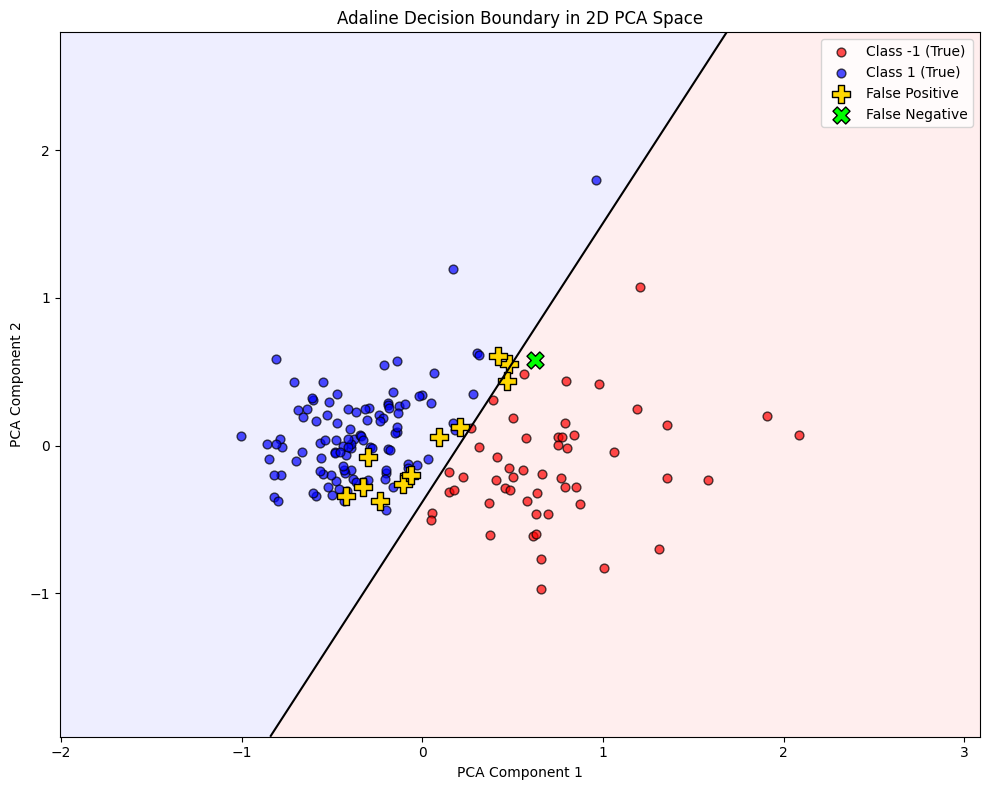

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#Fit PCA on training data and transform test data
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_test_norm)
X_test_pca = pca.transform(X_test_norm)

#Compute decision boundary in PCA space
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))


# Inverse transform grid points back to normalized feature space
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_original = pca.inverse_transform(grid_points)

# Compute Adaline decision scores for the grid
Z = best_model.net_input(grid_original)
Z = Z.reshape(xx.shape)


y_test_ada = np.where(y_test == 0, -1, 1)

#identify misclassifications
FP_idx = np.where((y_test_ada == -1) & (y_pred == 1))[0]  # True -1, predicted 1
FN_idx = np.where((y_test_ada == 1) & (y_pred == -1))[0]  # True 1, predicted -1



#Plot
plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, levels=[-9999, 0, 9999], alpha=0.2, colors=['#FFAAAA', '#AAAAFF'])
plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1.5)

plt.scatter(X_test_pca[y_test_ada == -1, 0], X_test_pca[y_test_ada == -1, 1],
            color='red', label='Class -1 (True)', edgecolor='k', s=40, alpha=0.7)
plt.scatter(X_test_pca[y_test_ada == 1, 0], X_test_pca[y_test_ada == 1, 1],
            color='blue', label='Class 1 (True)', edgecolor='k', s=40, alpha=0.7)

if len(FP_idx) > 0:
    plt.scatter(X_test_pca[FP_idx, 0], X_test_pca[FP_idx, 1],
                color='gold', edgecolor='black', marker='P', s=150, label='False Positive')

if len(FN_idx) > 0:
    plt.scatter(X_test_pca[FN_idx, 0], X_test_pca[FN_idx, 1],
                color='lime', edgecolor='black', marker='X', s=150, label='False Negative')

plt.title("Adaline Decision Boundary in 2D PCA Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.show()

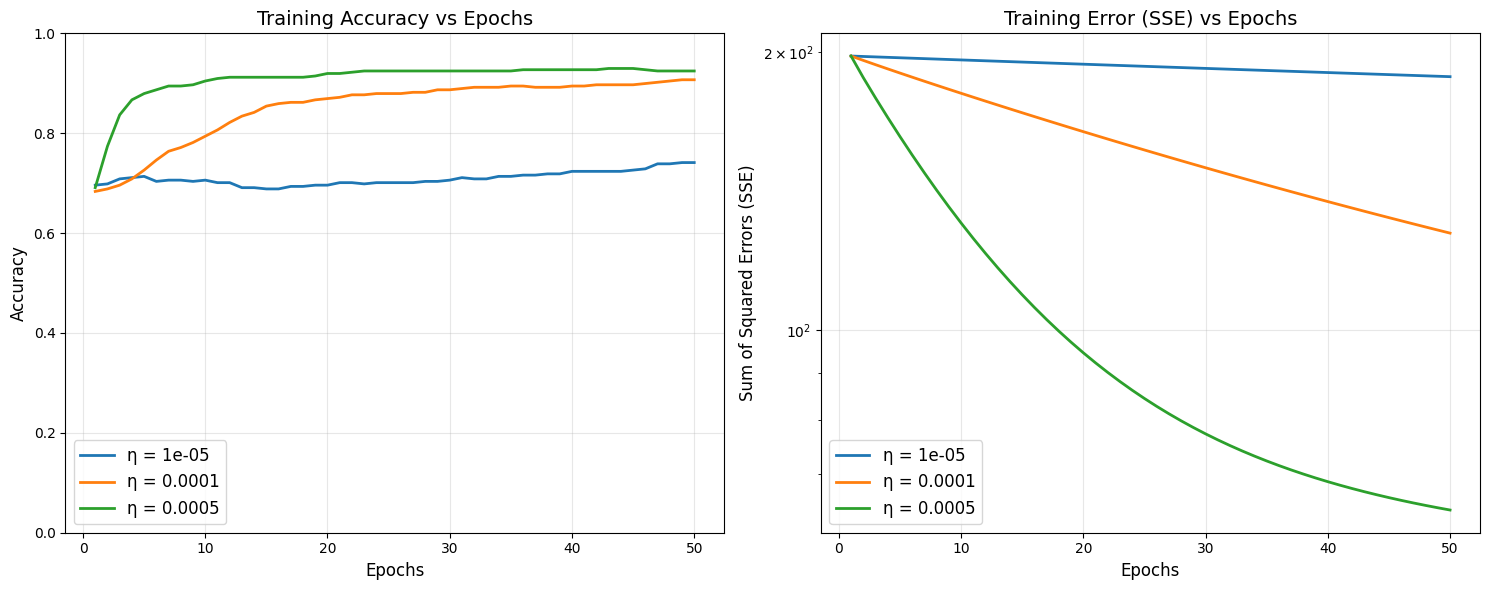

In [6]:
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Training Accuracy vs Epochs
for eta in etas:
    key = (eta, l2)
    if key in results:
        acc_curve = results[key]['acc_curve']
        epochs = range(1, len(acc_curve) + 1)
        ax1.plot(epochs, acc_curve, label=f'η = {eta}', linewidth=2)

ax1.set_title('Training Accuracy vs Epochs', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.0)

#Training Error (SSE) vs Epochs
for eta in etas:
    key = (eta, l2)
    if key in results:
        sse_curve = results[key]['sse_curve']
        epochs = range(1, len(sse_curve) + 1)
        ax2.plot(epochs, sse_curve, label=f'η = {eta}', linewidth=2)

ax2.set_title('Training Error (SSE) vs Epochs', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Sum of Squared Errors (SSE)', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

### 2-1-5

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Convert labels to {0,1} for sklearn models
y_train_bin = (y_train_ada == 1).astype(int)
y_test_bin = (y_test_ada == 1).astype(int)

# Train LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_norm, y_train_bin)
y_pred_lda = lda.predict(X_test_norm)
y_score_lda = lda.predict_proba(X_test_norm)[:, 1]

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=1)
lr.fit(X_train_norm, y_train_bin)
y_pred_lr = lr.predict(X_test_norm)
y_score_lr = lr.predict_proba(X_test_norm)[:, 1]

# Calculate metrics for all models
metrics = {
    'Adaline': {
        'Accuracy': accuracy_score(y_test_ada, y_pred),
        'Precision': precision_score(y_test_ada, y_pred, pos_label=1),
        'Recall': recall_score(y_test_ada, y_pred, pos_label=1),
        'F1': f1_score(y_test_ada, y_pred, pos_label=1),
        'ROC AUC': roc_auc_score(y_test_ada, y_score)
    },
    'LDA': {
        'Accuracy': accuracy_score(y_test_bin, y_pred_lda),
        'Precision': precision_score(y_test_bin, y_pred_lda),
        'Recall': recall_score(y_test_bin, y_pred_lda),
        'F1': f1_score(y_test_bin, y_pred_lda),
        'ROC AUC': roc_auc_score(y_test_bin, y_score_lda)
    },
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_bin, y_pred_lr),
        'Precision': precision_score(y_test_bin, y_pred_lr),
        'Recall': recall_score(y_test_bin, y_pred_lr),
        'F1': f1_score(y_test_bin, y_pred_lr),
        'ROC AUC': roc_auc_score(y_test_bin, y_score_lr)
    }
}

# Create comparison table
import pandas as pd
df_metrics = pd.DataFrame(metrics).T
print("Model Comparison Metrics:")
print(df_metrics.round(4))

Model Comparison Metrics:
                     Accuracy  Precision  Recall      F1  ROC AUC
Adaline                0.9240     0.8983  0.9907  0.9422   0.9740
LDA                    0.9532     0.9459  0.9813  0.9633   0.9855
Logistic Regression    0.9357     0.9286  0.9720  0.9498   0.9860


# 2-2

### 2-2-1


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


class ThreeLayerAdalineRII:
    def __init__(self, input_size, hidden_size, learning_rate=0.01, max_epochs=200,
                 lambda_l2=0.001, random_state=None):
        if random_state is not None:
            np.random.seed(random_state)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.lambda_l2 = lambda_l2

        # Xavier initialization (good for tanh)
        limit_W1 = np.sqrt(6 / (input_size + hidden_size))
        self.W1 = np.random.uniform(-limit_W1, limit_W1, (input_size, hidden_size))
        self.b1 = np.zeros(hidden_size)
        limit_W2 = np.sqrt(6 / (hidden_size + 1))
        self.W2 = np.random.uniform(-limit_W2, limit_W2, hidden_size)
        self.b2 = 0.0

        # tracking
        self.train_errors, self.train_accuracies = [], []
        self.test_errors, self.test_accuracies = [], []

    # --- Activations ---
    def activation(self, x):
        return np.tanh(x)

    def activation_deriv(self, x):
        return 1 - np.tanh(x) ** 2

    def sign(self, x):
        return np.where(x >= 0, 1, -1)

    # --- Forward Pass ---
    def forward(self, X):
        z1 = X.dot(self.W1) + self.b1
        h = self.activation(z1)
        z2 = h.dot(self.W2) + self.b2
        y = self.activation(z2)  # nonlinear output
        return z1, h, z2, y

    # --- Training (nonlinear MR-II) ---
    def fit(self, X_train, y_train, X_test=None, y_test=None, verbose=False):
        for epoch in range(self.max_epochs):
            n_updates = 0
            for i in range(X_train.shape[0]):
                xi = X_train[i:i+1]
                yi = y_train[i]

                # forward
                z1, h, z2, y = self.forward(xi)
                error = yi - y

                # Only update if misclassified (or large error)
                if np.sign(y) != yi or abs(error) > 0.1:
                    # L2 regularization
                    self.W1 *= (1 - self.lr * self.lambda_l2)
                    self.W2 *= (1 - self.lr * self.lambda_l2)

                    # --- Nonlinear MR-II update rule ---
                    # delta for output layer (tanh derivative)
                    delta2 = error * self.activation_deriv(z2)

                    # delta for hidden layer (each hidden neuron)
                    delta1 = delta2 * self.W2 * self.activation_deriv(z1)

                    # Update weights
                    self.W2 += self.lr * delta2 * h.ravel()
                    self.b2 += self.lr * delta2

                    self.W1 += self.lr * xi.T.dot(delta1)
                    self.b1 += self.lr * delta1.ravel()

                    n_updates += 1

            # --- evaluation ---
            y_train_pred = self.predict(X_train)
            train_error = np.mean(y_train_pred != y_train)
            train_acc = accuracy_score(y_train, y_train_pred)
            self.train_errors.append(train_error)
            self.train_accuracies.append(train_acc)

            if X_test is not None:
                y_test_pred = self.predict(X_test)
                test_error = np.mean(y_test_pred != y_test)
                test_acc = accuracy_score(y_test, y_test_pred)
                self.test_errors.append(test_error)
                self.test_accuracies.append(test_acc)

            if verbose and ((epoch + 1) % 20 == 0 or epoch == 0):
                msg = f"Epoch {epoch+1}/{self.max_epochs} - train_acc: {train_acc:.3f}, err: {train_error:.3f}"
                if X_test is not None:
                    msg += f", test_acc: {test_acc:.3f}, test_err: {test_error:.3f}"
                print(msg)

            if n_updates == 0:
                if verbose:
                    print(f"Early stop at epoch {epoch+1} (no updates).")
                break

    # --- Prediction ---
    def predict(self, X):
        _, _, _, y = self.forward(X)
        return self.sign(y)

    def predict_proba(self, X):
        _, _, _, y = self.forward(X)
        return (y + 1) / 2  # scale tanh output to [0,1]


    def get_hidden_layer_outputs(self, X):
        _, h, _, _ = self.forward(X)
        return h




### 2-2-2 , 2-2-3

In [9]:
# -------------------------
# Utility functions & experiment runner for ThreeLayerAdalineRII (tanh + sign + Rule II + L2)
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from matplotlib.colors import ListedColormap


# --- Evaluation ---
def evaluate_model(model, X_test, y_test, dataset_name):
    y_pred = model.predict(X_test)
    _, _, _, y_raw = model.forward(X_test)
    y_proba = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min() + 1e-8)  # normalize for AUC

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score((y_test == 1).astype(int), y_proba)

    return {
        "confusion_matrix": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc
    }


# --- Dataset generation ---
def generate_dataset(dataset_type, random_state):
    if dataset_type == 'moons':
        X, y = make_moons(n_samples=600, noise=0.25, random_state=random_state)
    elif dataset_type == 'circles':
        X, y = make_circles(n_samples=600, noise=0.1, factor=0.5, random_state=random_state)
    else:
        raise ValueError("Invalid dataset type. Use 'moons' or 'circles'.")
    y = np.where(y == 0, -1, 1)
    return X, y


# --- Visualization: decision boundary ---
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_points = ListedColormap(['red', 'blue'])

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=(y == 1).astype(int),
                cmap=cmap_points, edgecolors='k', s=40)

    y_pred = model.predict(X)
    fp = (y == -1) & (y_pred == 1)
    fn = (y == 1) & (y_pred == -1)
    if np.any(fp):
        plt.scatter(X[fp, 0], X[fp, 1], s=140, facecolors='none', edgecolors='green',
                    linewidths=2, label='False Positive')
    if np.any(fn):
        plt.scatter(X[fn, 0], X[fn, 1], s=140, facecolors='none', edgecolors='red',
                    linewidths=2, label='False Negative')

    plt.title(title)
    plt.legend()
    plt.show()


# --- Visualization: hidden layer boundaries ---
def plot_hidden_layer_boundaries(model, X, y, title="Hidden Layer Boundaries"):
    H = model.get_hidden_layer_outputs(X)
    n_hidden = model.hidden_size
    cols = min(4, n_hidden)
    rows = int(np.ceil(n_hidden / cols))
    plt.figure(figsize=(4 * cols, 3 * rows))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

    for i in range(n_hidden):
        plt.subplot(rows, cols, i + 1)
        w = model.W1[:, i]
        b = model.b1[i]
        if abs(w[1]) > 1e-8:
            x_vals = np.array([x_min, x_max])
            y_vals = (-w[0] * x_vals - b) / w[1]
            plt.plot(x_vals, y_vals, 'k-')
        plt.scatter(X[:, 0], X[:, 1], c=(H[:, i] > 0).astype(int), edgecolors='k')
        plt.title(f'Hidden Unit {i + 1}')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- Visualization: learning curves ---
def plot_learning_curves(model, title="Learning Curves"):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(model.train_errors, label='Train Error')
    if model.test_errors:
        plt.plot(model.test_errors, label='Test Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.legend()
    plt.title('Error vs Epoch')

    plt.subplot(1, 2, 2)
    plt.plot(model.train_accuracies, label='Train Acc')
    if model.test_accuracies:
        plt.plot(model.test_accuracies, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs Epoch')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# --- Main experiment runner ---
def run_experiment(dataset_type, hidden_sizes, learning_rates, l2_lambdas,
                   random_state=0, max_epochs=400):
    from copy import deepcopy
    X, y = generate_dataset(dataset_type, random_state=random_state)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    best_model = None
    best_score = -1
    results = []

    for hidden_size in hidden_sizes:
        for lr in learning_rates:
            for l2 in l2_lambdas:
                model = ThreeLayerAdalineRII(
                    input_size=X_train.shape[1],
                    hidden_size=hidden_size,
                    learning_rate=lr,
                    max_epochs=max_epochs,
                    lambda_l2=l2,
                    random_state=random_state
                )

                model.fit(X_train, y_train, X_test=X_test, y_test=y_test, verbose=False)
                metrics = evaluate_model(model, X_test, y_test, dataset_type)
                metrics.update({
                    'hidden_size': hidden_size,
                    'learning_rate': lr,
                    'lambda_l2': l2
                })
                results.append(metrics)

                if metrics['accuracy'] > best_score:
                    best_score = metrics['accuracy']
                    best_model = deepcopy(model)

    return {
        'best_model': best_model,
        'results': results,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'X': X,
        'y': y
    }


# --- Full workflow wrapper ---
def run_and_report(dataset_name, hidden_sizes, learning_rates, l2_lambdas):
    print(f"\nRunning experiment for {dataset_name} dataset...")
    results = run_experiment(dataset_name, hidden_sizes, learning_rates, l2_lambdas,
                             random_state=0, max_epochs=400)

    if results['best_model'] is None:
        print(f"No valid model found for {dataset_name}.")
        return

    best = results['best_model']
    best_result = max(results['results'], key=lambda x: x['accuracy'])

    print("\nBest model hyperparams (approx):")
    print(best_result)

    eval_metrics = evaluate_model(best, results['X_test'], results['y_test'], dataset_name)

    plot_decision_boundary(best, results['X_test'], results['y_test'],
                           title=f"Decision Boundary for {dataset_name}")
    plot_hidden_layer_boundaries(best, results['X_test'], results['y_test'],
                                 title=f"Hidden Layer Boundaries for {dataset_name}")
    plot_learning_curves(best, title=f"Learning Curves for {dataset_name}")

    return eval_metrics



Running experiment for moons dataset...

Best model hyperparams (approx):
{'confusion_matrix': array([[87,  5],
       [12, 76]]), 'accuracy': 0.9055555555555556, 'precision': 0.9382716049382716, 'recall': 0.8636363636363636, 'f1': 0.8994082840236687, 'roc_auc': np.float64(0.9607213438735178), 'hidden_size': 5, 'learning_rate': 0.001, 'lambda_l2': 0}


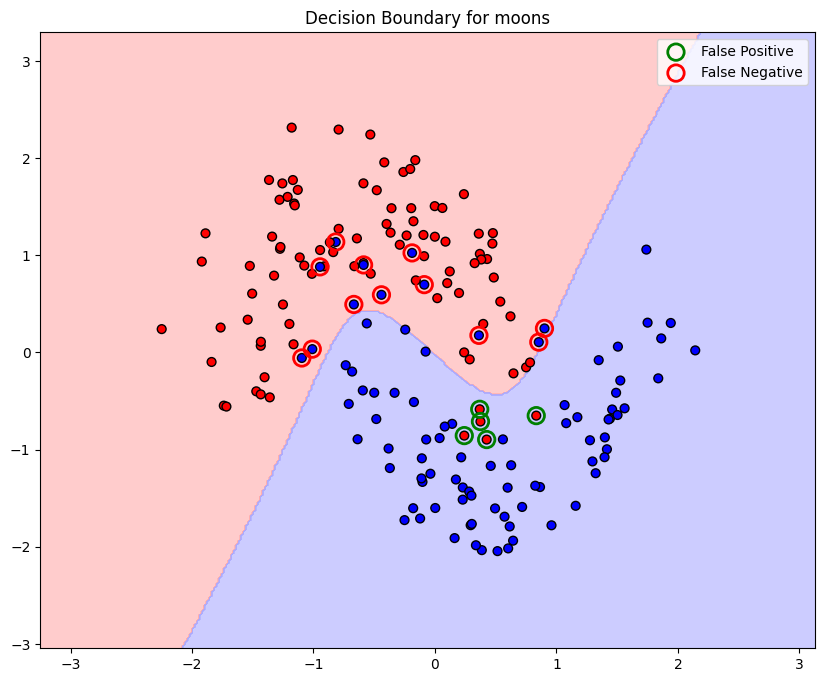

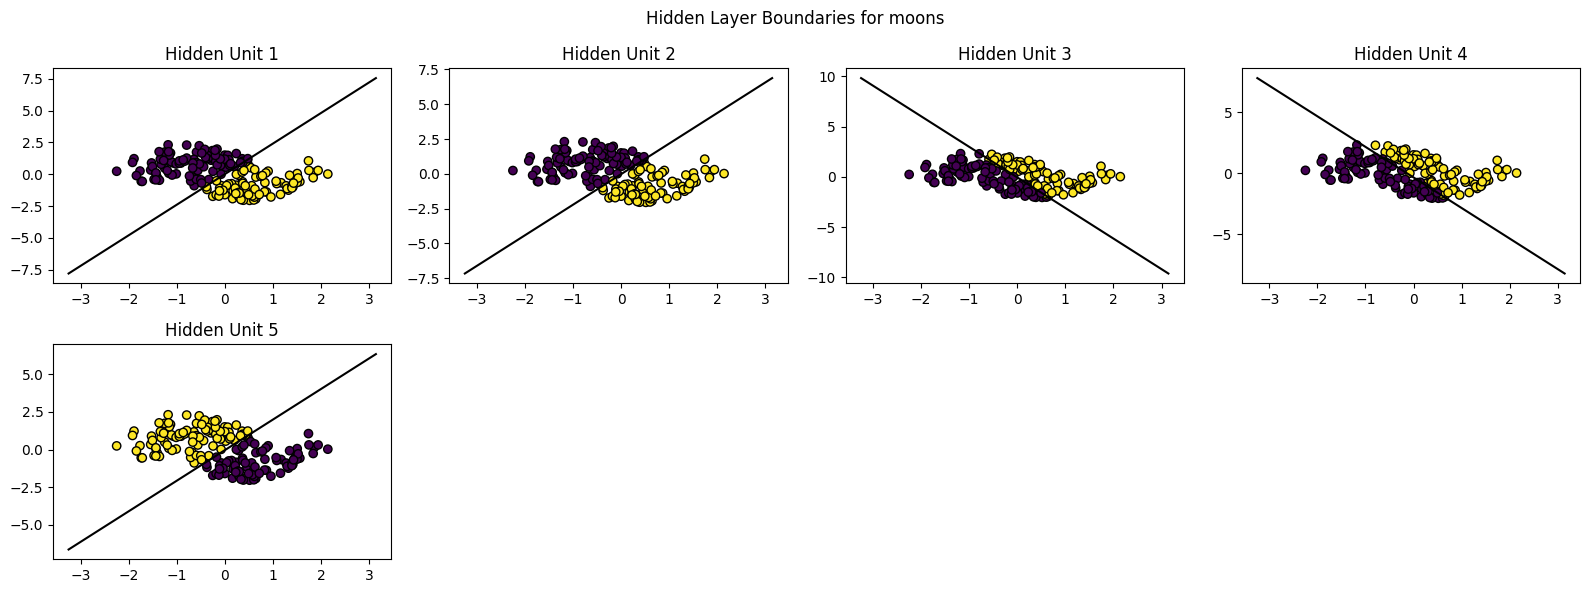

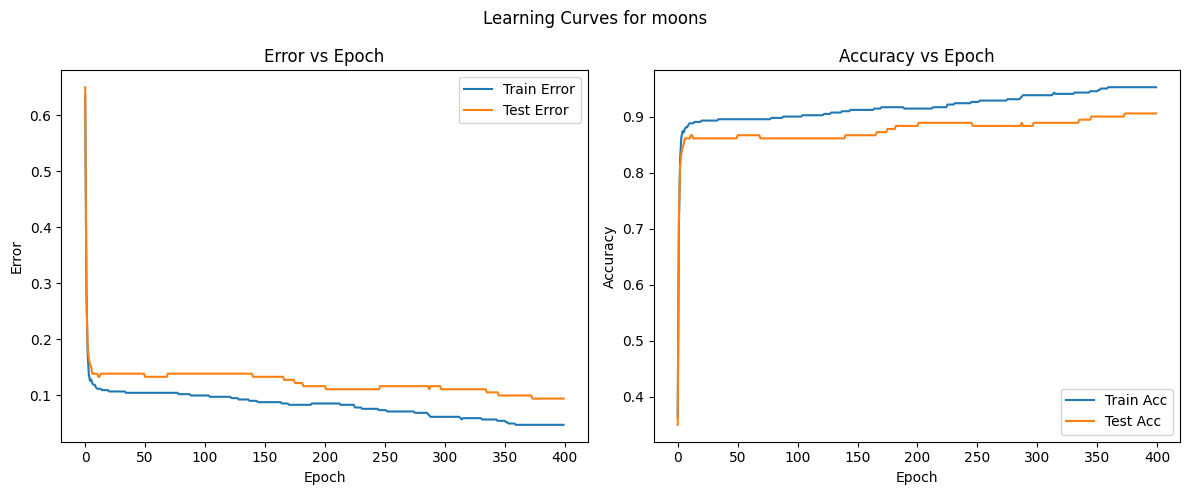


Running experiment for circles dataset...

Best model hyperparams (approx):
{'confusion_matrix': array([[91,  1],
       [ 2, 86]]), 'accuracy': 0.9833333333333333, 'precision': 0.9885057471264368, 'recall': 0.9772727272727273, 'f1': 0.9828571428571429, 'roc_auc': np.float64(0.9975296442687747), 'hidden_size': 5, 'learning_rate': 0.001, 'lambda_l2': 0}


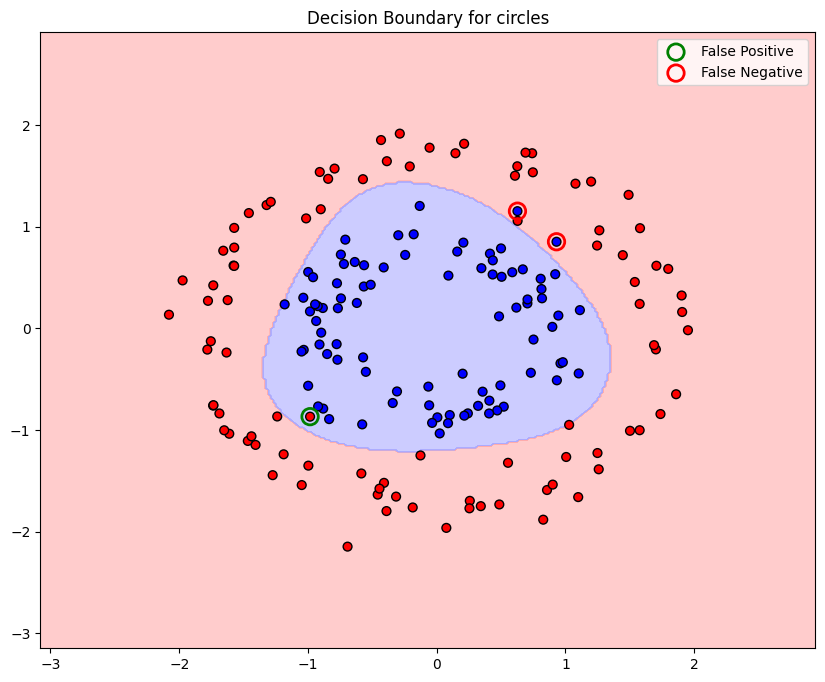

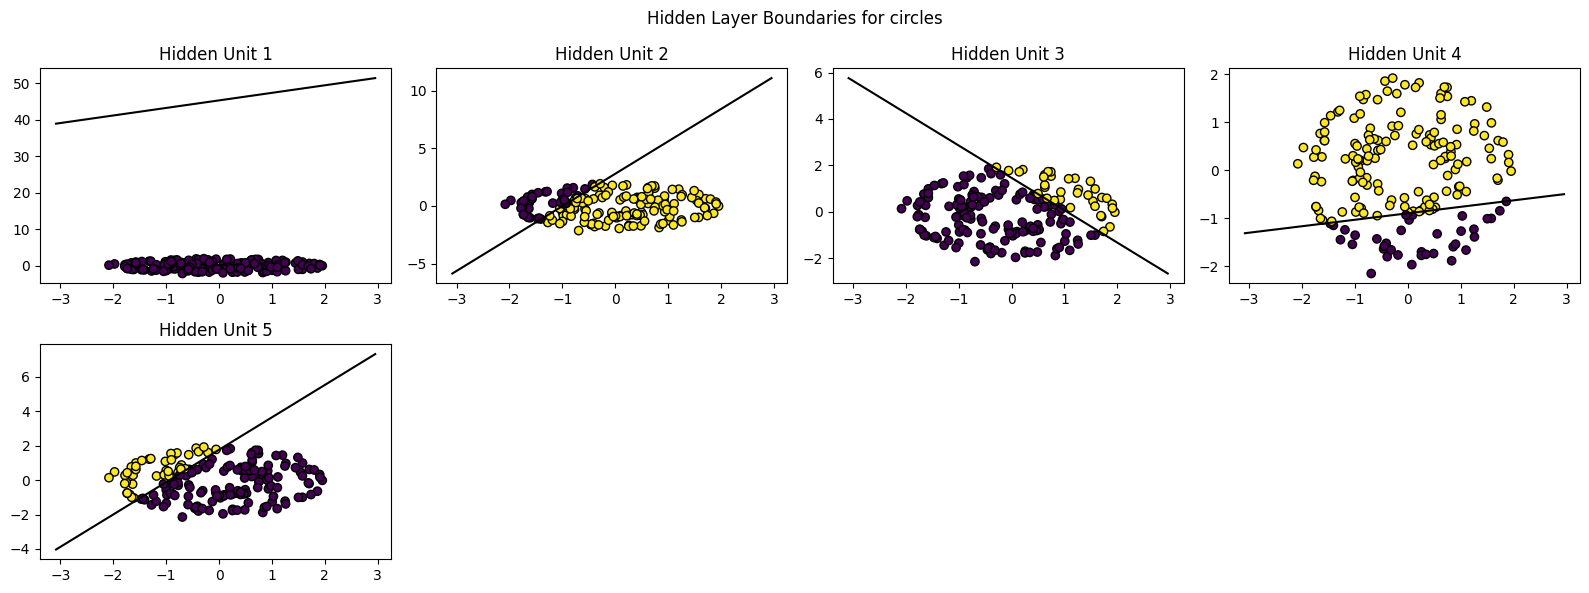

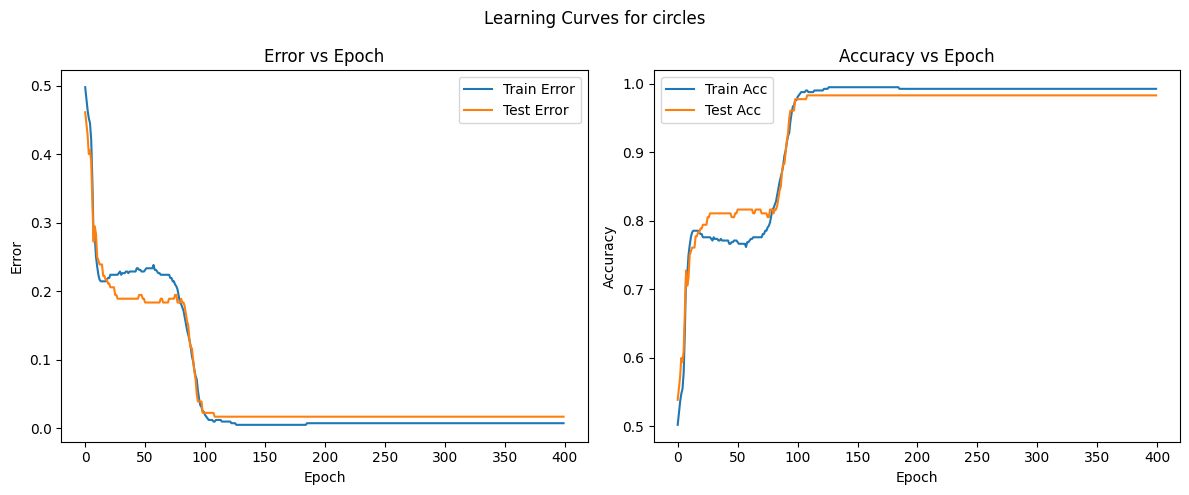

In [10]:

hidden_sizes = [3,5,7,10]
learning_rates = [0.001]
l2_lambdas = [0,.001]


moons_metrics = run_and_report('moons', hidden_sizes, learning_rates, l2_lambdas)
circles_metrics = run_and_report('circles', hidden_sizes, learning_rates, l2_lambdas)




### 2-2-4

In [20]:
def print_best_per_seed(dataset_name, hidden_sizes, learning_rates, l2_lambdas, seeds=(0, 1, 2)):
    for seed in seeds:
        results = run_experiment(
            dataset_name,
            hidden_sizes,
            learning_rates,
            l2_lambdas,
            random_state=seed,
            max_epochs=400
        )
        best_model_info = results['best_model']
        eval_metrics = evaluate_model(best_model_info, results['X_test'], results['y_test'], dataset_name)

        print(f"\n=== Seed {seed} ===")
        print(f"dataset: {dataset_name}")
        print("Metrics:")
        for metric, value in eval_metrics.items():
            if not isinstance(value, (np.ndarray, list)):  # skip confusion matrix
                print(f"{metric}: {value}")

        print("Hyperparameters:")
        print(f"hidden_size: {best_model_info.hidden_size}")
        print(f"learning_rate: {best_model_info.lr}")
        print(f"lambda_l2: {best_model_info.lambda_l2}")


In [21]:

moons_summary = print_best_per_seed('moons', hidden_sizes, learning_rates, l2_lambdas)
circles_summary = print_best_per_seed('circles', hidden_sizes, learning_rates, l2_lambdas)



=== Seed 0 ===
dataset: moons
Metrics:
accuracy: 0.9055555555555556
precision: 0.9382716049382716
recall: 0.8636363636363636
f1: 0.8994082840236687
roc_auc: 0.9607213438735178
Hyperparameters:
hidden_size: 5
learning_rate: 0.001
lambda_l2: 0

=== Seed 1 ===
dataset: moons
Metrics:
accuracy: 0.9277777777777778
precision: 0.9574468085106383
recall: 0.9090909090909091
f1: 0.9326424870466321
roc_auc: 0.9872802095024317
Hyperparameters:
hidden_size: 3
learning_rate: 0.001
lambda_l2: 0

=== Seed 2 ===
dataset: moons
Metrics:
accuracy: 0.9222222222222223
precision: 0.90625
recall: 0.9456521739130435
f1: 0.925531914893617
roc_auc: 0.981348814229249
Hyperparameters:
hidden_size: 5
learning_rate: 0.001
lambda_l2: 0.001

=== Seed 0 ===
dataset: circles
Metrics:
accuracy: 0.9833333333333333
precision: 0.9885057471264368
recall: 0.9772727272727273
f1: 0.9828571428571429
roc_auc: 0.9975296442687747
Hyperparameters:
hidden_size: 5
learning_rate: 0.001
lambda_l2: 0

=== Seed 1 ===
dataset: circles
Me